<a href="https://colab.research.google.com/github/OPCIO0568/2026-1_CV/blob/main/HW%232-10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

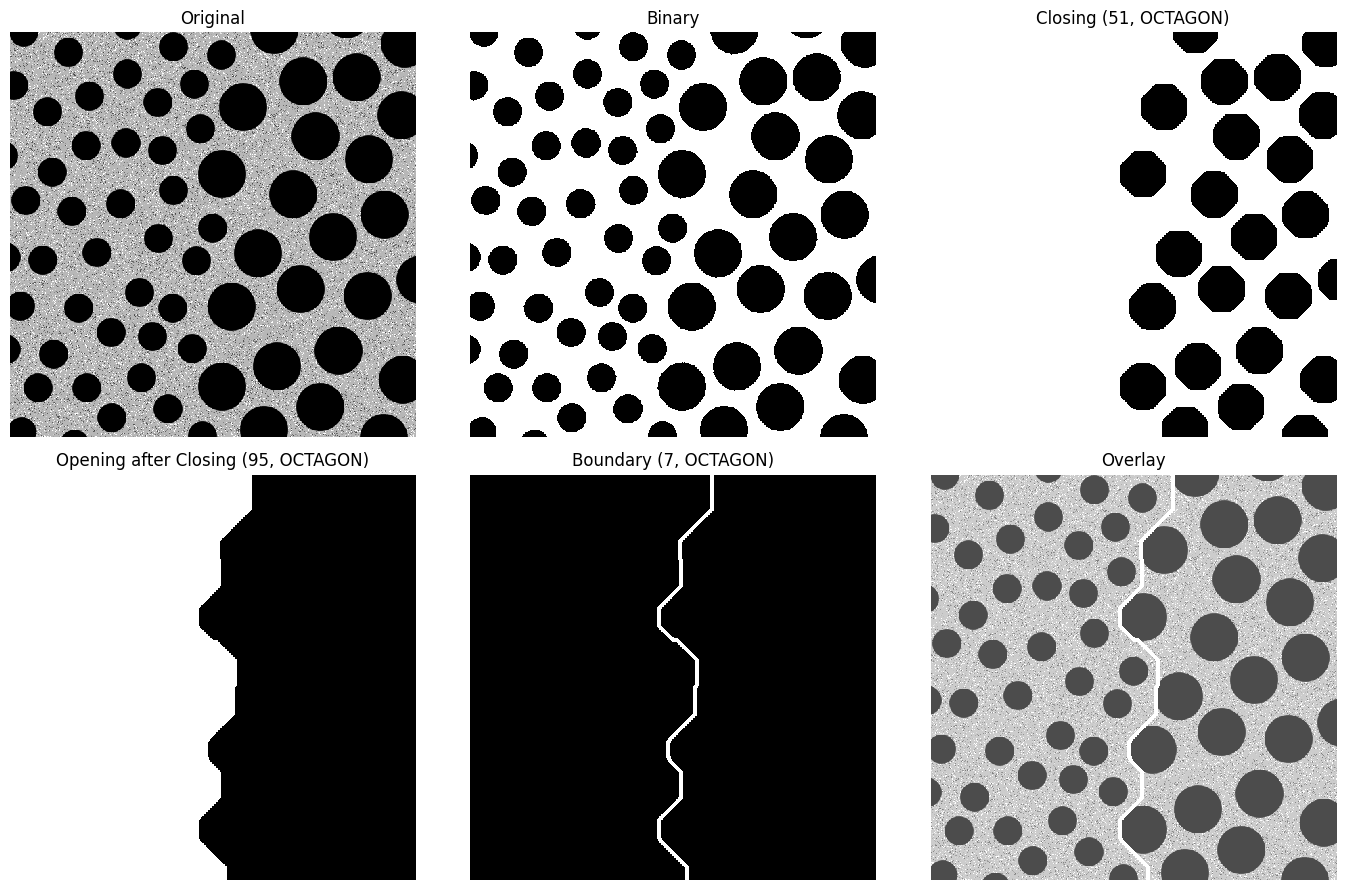

In [46]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('/content/Fig0943(a)(dark_blobs_on_light_background).tif', cv2.IMREAD_GRAYSCALE)
if img is None:
    raise ValueError("이미지를 불러오지 못했습니다.")

# -------------------------------
# 8각형 구조요소 생성 함수
# -------------------------------
def make_octagon_kernel(size, cut_ratio=0.3):

    k = np.zeros((size, size), dtype=np.uint8)

    cut = int(round(size * cut_ratio))
    cut = max(1, min(cut, size // 2 - 1))

    pts = np.array([
        [cut, 0],
        [size - cut - 1, 0],
        [size - 1, cut],
        [size - 1, size - cut - 1],
        [size - cut - 1, size - 1],
        [cut, size - 1],
        [0, size - cut - 1],
        [0, cut]
    ], dtype=np.int32)

    cv2.fillPoly(k, [pts], 1)
    return k

# 이진화
_, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
binary = cv2.medianBlur(binary, 3)

# -------------------------------
# 8각형 SE 사용
# -------------------------------
# 가능하면 홀수 크기 권장
close_size = 51
open_size = 95
grad_size = 7

se_close = make_octagon_kernel(close_size, cut_ratio=0.3)
se_open  = make_octagon_kernel(open_size, cut_ratio=0.3)
se_grad  = make_octagon_kernel(grad_size, cut_ratio=0.3)

closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, se_close)
opened = cv2.morphologyEx(closed, cv2.MORPH_OPEN, se_open)
boundary = cv2.morphologyEx(opened, cv2.MORPH_GRADIENT, se_grad)

overlay = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
overlay[boundary > 0] = [255, 255, 255]

titles = [
    'Original',
    'Binary',
    f'Closing ({close_size}, OCTAGON)',
    f'Opening after Closing ({open_size}, OCTAGON)',
    f'Boundary ({grad_size}, OCTAGON)',
    'Overlay'
]
images = [img, binary, closed, opened, boundary, overlay]

plt.figure(figsize=(14, 9))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    if i == 5:
        plt.imshow(images[i], interpolation='nearest')
    else:
        plt.imshow(images[i], cmap='gray', interpolation='nearest')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
|